# Bioimage Segmentation:
## Geometric Methods

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount = True)
dir_path = '/010-segmentation-geo/'  # Path to the folder

os.chdir(dir_path)

In [ ]:
%pip install ipywidgets


## Threshold-based segmentation





### Curve Fitting

Curve fitting is a fundamental technique used in threshold-based segmentation. It involves creating a mathematical curve that best fits a set of data points. This curve helps in identifying the optimal threshold value for segmenting an image. By fitting a curve to the intensity histogram of the image, we can determine the threshold that separates the foreground from the background effectively.

In [ ]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import asarray as ar,exp

x = ar(range(10))
y = ar([0, 1, 2, 3, 4, 5, 4, 3, 2, 1])

n = len(x)
mean = sum(x*y)/n
sigma = sum(y*(x - mean)**2)/n

def gauss(x, a, x0, sigma):
    return a*exp(-(x-x0)**2/ (2*sigma**2))

poptm, pcov = curve_fit(gauss,x, y, p0 = [1, mean, sigma])
plt.plot(x, y, 'b+:', label = 'data')
plt.plot(x, gauss(x, *poptm), 'ro:', label = 'fit')
plt.legend()
plt.title('Fit for time constant')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.show()

### Gaussian Mixture Model

The Gaussian Mixture Model (GMM) is a probabilistic approach used in threshold-based segmentation. It models the intensity distribution of an image as a mixture of multiple Gaussian distributions, each representing a distinct component or cluster in the data. By fitting a GMM to the image histogram, we can identify different intensity peaks corresponding to different segments. The model assigns probabilities to each pixel, indicating its likelihood of belonging to each Gaussian component. The threshold value for segmentation is then determined based on these probabilities, typically by selecting the value where the overlapping Gaussian distributions intersect. GMM is particularly useful for images with complex intensity distributions, providing a robust method for segmenting diverse regions accurately.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from skimage import color


img = cv2.imread('edge_thresh.jpg')

img_gray_bins = color.rgb2gray(img).reshape(-1, 1)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.GaussianBlur(gray, (5,5), 0)

pixels = gray_blurred.reshape(-1,1)

n_components = 2
gmm = GaussianMixture(n_components=n_components, covariance_type='tied', random_state=42)


gmm.fit(pixels)
labels = gmm.predict(pixels)
segmented_image = labels.reshape(gray.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color.rgb2gray(img), cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Histogram
hist, bins_center = np.histogram(img_gray_bins, bins=256, range=(0, 1))
axes[1].plot(bins_center[1:], hist)
axes[1].set_title('Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')

# Segmented image
axes[2].imshow(segmented_image, cmap='viridis')
axes[2].set_title('Segmented Image (GMM)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Region-based segmentation

 This method is designed for multi-channel images, such as RGB or multi-spectral medical images, and allows for precise segmentation based on the statistical properties of the image regions. By initializing the segmentation with seed points, the algorithm grows regions iteratively, incorporating neighboring pixels that are similar in intensity within a defined confidence interval. We will load an image, specify seed points, and adjust parameters like the neighborhood radius, multiplier, and number of iterations to achieve accurate segmentation results. This approach is particularly useful for isolating specific structures or areas within complex images.

In [ ]:
%pip install SimpleITK

In [ ]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
from downloaddata import fetch_data as fdata
import cv2

In [ ]:
mr_image = sitk.ReadImage(fdata("training_001_mr_T1.mha"))
image_array = sitk.GetArrayFromImage(mr_image)

def normalize(image):
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

axial_slice_1 = normalize(image_array[6, :, :])  # Axial slice 1 (quarter depth)
axial_slice_2 = normalize(image_array[13, :, :])  # Axial slice 2 (half depth)
sagittal_slice = normalize(image_array[25, :, :])  # Sagittal slice (middle of the volume)

fig, axes = plt.subplots(3, 1, figsize=(5, 15))

axes[0].imshow(axial_slice_1, cmap='gray')
axes[0].set_title('Axial Slice 1')
axes[0].axis('off')

axes[1].imshow(axial_slice_2, cmap='gray')
axes[1].set_title('Axial Slice 2')
axes[1].axis('off')

axes[2].imshow(sagittal_slice, cmap='gray')
axes[2].set_title('Sagittal Slice')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
image = image_array[6, :, :]
image = sitk.GetImageFromArray(image)

print(f"Image dimension: {image.GetDimension()}")
print(f"Image pixel type: {image.GetPixelIDTypeAsString()}")

image = sitk.Cast(image, sitk.sitkFloat32)

seed_point = (100, 100)

initial_neighborhood_radius = 1
multiplier = 2.5
number_of_iterations = 10

segmented_image = sitk.ConfidenceConnected(
    image,
    seedList=[seed_point],
    numberOfIterations=number_of_iterations,
    multiplier=multiplier,
    initialNeighborhoodRadius=initial_neighborhood_radius,
    replaceValue=1
)

segmented_array = sitk.GetArrayViewFromImage(segmented_image)

# Visualize the original and segmented images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(sitk.GetArrayViewFromImage(image), cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(segmented_array, cmap='gray')
ax[1].set_title('Segmented Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()


## Watershed image segmentation


### Morphological Operations



*   Erosion
*   Dilation
*   Opening
*   Closing






In [ ]:
# Through skimage

import numpy as np
from skimage.morphology import square, erosion, dilation


bright_square = np.array([[0, 0, 0, 0, 0],
                         [0, 1, 1, 1, 0],
                         [0, 1, 1, 1, 0],
                         [0, 1, 1, 1, 0],
                         [0, 0, 0, 0, 0]], dtype=np.uint8)

erosion(bright_square, square(3))

In [ ]:
bright_pixel = np.array([[0, 0, 0, 0, 0],
                         [0, 0, 0, 0, 0],
                         [0, 0, 1, 0, 0],
                         [0, 0, 0, 0, 0],
                         [0, 0, 0, 0, 0]], dtype=np.uint8)

dilation(bright_pixel, square(3))

In [ ]:
# Visualization through OpenCV

import cv2
import numpy as np
from matplotlib import pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

image = cv2.imread('edge_thresh.jpg', cv2.IMREAD_GRAYSCALE)

_, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)


def morphological_operations(kernel_size):

    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    dilated = cv2.dilate(binary_image, kernel, iterations=1)
    eroded = cv2.erode(binary_image, kernel, iterations=1)
    opened = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

    titles = ['Original Image', 'Binary Image', 'Dilated', 'Eroded', 'Opened', 'Closed']
    images = [image, binary_image, dilated, eroded, opened, closed]

    fig, axes = plt.subplots(2, 3, figsize=(10, 10))
    for ax, title, img in zip(axes.flatten(), titles, images):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

interact(morphological_operations, kernel_size=widgets.IntSlider(min=1, max=21, step=2, value=5))


### WaterShed segmentation through OpenCV

Watershed segmentation is a powerful technique for separating overlapping objects in an image using the analogy of topographic landscape flooding. In OpenCV, this method involves treating the grayscale image as a topographic surface where light pixels represent high elevations, and dark pixels represent low elevations. The process begins with marking the foreground and background regions. These markers are then used to initiate flooding from these points until they meet, creating watershed lines that define the boundaries of segments.


### Oversegmentation

Oversegmentation is a common issue in image segmentation where an image is divided into too many small regions, making it difficult to identify meaningful objects. This often occurs when using segmentation techniques like the Watershed algorithm on noisy images or images with subtle intensity variations.

To address oversegmentation, marker-based approaches are employed. This method involves using predefined markers to guide the segmentation process, ensuring that regions are merged appropriately and meaningful objects are correctly identified.

In [ ]:
from skimage import data
from skimage.filters import sobel
from skimage.segmentation import watershed
import matplotlib.pyplot as plt


coins_arr = data.coins()
markers = np.zeros_like(coins_arr)
markers[coins_arr < 30] = 1
markers[coins_arr > 150] = 2


elevation_map = sobel(coins_arr)
segmentation = watershed(elevation_map, markers)


titles = ["coins_arr", "elevation_map", "markers" ,"segmentation"]
images = [coins_arr, elevation_map, markers, segmentation]


fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, title, img in zip(axes.flatten(), titles, images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### SLIC for over-segmentation

Simple Linear Iterative Clustering (SLIC) is an efficient algorithm used to achieve superpixel segmentation, which is a form of oversegmentation. Superpixels group pixels into perceptually meaningful atomic regions that can be used for further processing tasks. SLIC leverages k-means clustering to segment an image into superpixels based on color similarity and proximity, providing a compact and uniform oversegmentation.

In [ ]:
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage import io
import matplotlib.pyplot as plt

image_path = 'edge_thresh.jpg'
image = img_as_float(io.imread(image_path))

for numSegments in (100, 200, 300):
    segments = slic(image, n_segments=numSegments, sigma=5)

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(mark_boundaries(image, segments))
    ax.set_title(f"Superpixels -- {numSegments} segments")

    plt.axis('off')

plt.show()

## Active contour based segmentation

Active contour models, also known as snakes, are used for object boundary detection in image segmentation. These models evolve a curve to fit the object boundaries by minimizing an energy function. Skimage provides tools to implement active contour-based segmentation efficiently.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import active_contour
from skimage.filters import gaussian

image = cv2.imread('edge_thresh.jpg', cv2.IMREAD_GRAYSCALE)
blurred = gaussian(image, sigma=3)

s = np.linspace(0, 2 * np.pi, 400)
r = 50 + 50 * np.sin(s)
c = 50 + 50 * np.cos(s)
init_contour = np.array([r, c]).T

snake = active_contour(blurred, init_contour, alpha=0.015, beta=10, gamma=0.001)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image, cmap='gray')
ax[0].plot(init_contour[:, 1], init_contour[:, 0], '--r', lw=2)
ax[0].set_title('Initial Contour')

ax[1].imshow(image, cmap='gray')
ax[1].plot(snake[:, 1], snake[:, 0], '-b', lw=2)
ax[1].set_title('Active Contour')

plt.show()

## Chan-Vese level set segmentation




Chan-Vese level set segmentation is a region-based approach that segments an image by evolving a contour to capture regions with similar intensity values. It does not rely on detecting edges, making it effective for separating objects with smooth boundaries or weak edges. This technique is particularly useful for segmenting images where the foreground and background have distinct average intensities, even if the edges between them are not well defined.

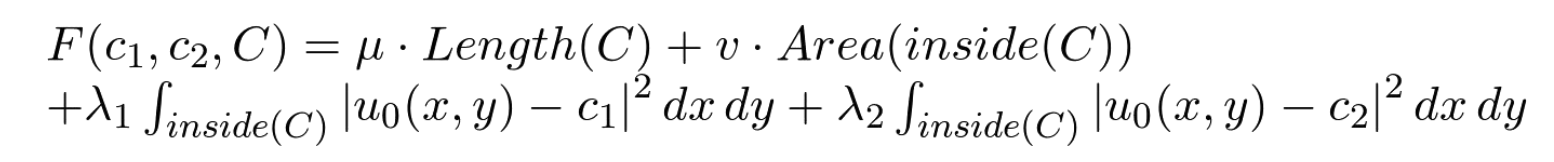

mu: float, optional
‘edge length’ weight parameter. Higher mu values will produce a ‘round’ edge, while values closer to zero will detect smaller objects.

nu:" 'area' weight parameter. Not implemented for this function in the skimage library.

lambda1: float, optional
‘difference from average’ weight parameter for the output region with value ‘True’. If it is lower than lambda2, this region will have a larger range of values than the other.

lambda2: float, optional
‘difference from average’ weight parameter for the output region with value ‘False’. If it is lower than lambda1, this region will have a larger range of values than the other.

In [ ]:
import cv2
from skimage.segmentation import chan_vese
import matplotlib.pyplot as plt

image_path = 'edge_thresh.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the image to grayscale for Chan-Vese segmentation
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Chan-Vese Segmentation
chan_vese_segmented = chan_vese(
    image_gray,
    mu=0.25,
    tol=1e-3,
    max_num_iter=200,
    dt=0.5,
    init_level_set="checkerboard"
)

# Plotting the original, grayscale, and Chan-Vese segmented images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap='gray')
axes[1].set_title("Original Image in Grayscale")
axes[1].axis("off")

axes[2].imshow(chan_vese_segmented, cmap='gray')
axes[2].set_title("Chan-Vese Segmentation")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Graph-cut based segmentation

Graph-cut based segmentation is a robust method for separating the foreground from the background in an image.  It represents the image as a graph, where pixels or groups of pixels (like superpixels) are treated as nodes, and edges represent the similarity between connected nodes (based on color, texture, etc.). The algorithm then “cuts” the graph to minimize dissimilarity between nodes on either side of the cut, effectively separating the image into meaningful segments, such as foreground and background. This approach is powerful for handling complex images with varying textures and colors.

#### Workflow:

1. The SLIC algorithm from the skimage.segmentation module is applied to the RGB image to generate superpixels. Parameters include the number of segments, compactness of the segments, and a smoothing factor (sigma).

2. A Region Adjacency Graph (RAG) is created using the labels from the SLIC segmentation. The rag_mean_color function computes mean colors for each region and uses these to build the graph, emphasizing similarity based on mean color.

3. The normalized cut algorithm is applied to the RAG to partition the graph into segments that minimize the total dissimilarity between different groups while maximizing the similarity within them.


In [ ]:
import cv2
from skimage import segmentation, color
from skimage.graph import rag_mean_color, cut_normalized
import matplotlib.pyplot as plt

image_path = "edge_thresh.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

labels = segmentation.slic(
    image_rgb,
    n_segments=250,
    compactness=10,
    sigma=1,
    start_label=1
)

# Build a Region Adjacency Graph (RAG) from the SLIC labels
rag = rag_mean_color(image_rgb, labels, mode='similarity')

# Apply normalized cuts to the RAG
graph_cut_labels = cut_normalized(labels, rag)

# Visualize the graph-cut segmentation
graph_cut_segmented = color.label2rgb(graph_cut_labels, image_rgb, kind='avg')

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(graph_cut_segmented)
axes[1].set_title("Graph-Cut Segmentation (RAG)")
axes[1].axis("off")

plt.tight_layout()
plt.show()
